In [1]:
import pandas as pd
from evaluation.nli.helpers import df_to_latex
from utils import DATA_DIR
from collections import defaultdict
import numpy as np
from models.encoder.text2features import FeatureExtractorPipeline
from models.encoder.text2features_paths import FEATURE_PIPELINE_RESOURCES
import matplotlib.pyplot as plt
from tqdm import tqdm
import matplotlib as mpl

extractors = FeatureExtractorPipeline(resources=FEATURE_PIPELINE_RESOURCES)

/home/terra/Projects/vis-desc/modules/lab/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-03 00:03:21.802178: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-03 00:03:21.918456: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-03 00:03:22.028325: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772492602.118995  128720 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772492602.144202  128720

using device cpu


In [2]:
ds_small_unbalanced = pd.read_parquet(
    DATA_DIR / "datasets" / "small" / "agreed.parquet"
)
ds_small_train = pd.read_parquet(DATA_DIR / "datasets" / "small" / "train.parquet")
ds_small_test = pd.read_parquet(DATA_DIR / "datasets" / "small" / "test.parquet")
ds_small = pd.concat([ds_small_train, ds_small_test], ignore_index=True)

In [11]:
def compute_dataset_stats(df, dataset_col=None, desc="Computing statistics"):
    """
    Compute comprehensive statistics for a dataset.

    Args:
        df: DataFrame with 'text' column
        dataset_col: Optional column name for per-dataset breakdown
        desc: Description for progress bar

    Returns:
        Dictionary with all computed statistics
    """
    total_token_count = 0
    total_sentence_count = 0
    total_vocab = set()

    doc_token_counts = []
    doc_sentence_counts = []
    doc_char_lengths = []

    token_count_by_dataset = {}
    sentence_count_by_dataset = {}
    vocab_by_dataset = defaultdict(set)

    doc_token_counts_by_dataset = defaultdict(list)
    doc_sentence_counts_by_dataset = defaultdict(list)
    doc_char_lengths_by_dataset = defaultdict(list)

    for index, row in tqdm(df.iterrows(), total=len(df), desc=desc):
        text = row["text"]
        ctx = extractors.get_ctx(text)
        token_count = len(ctx.tokens)
        sentence_count = len(ctx.sents)

        total_token_count += token_count
        total_sentence_count += sentence_count
        lemmas = [token.lemma for token in ctx.tokens]
        total_vocab.update(lemmas)

        doc_token_counts.append(token_count)
        doc_sentence_counts.append(sentence_count)
        doc_char_lengths.append(len(text))

        if dataset_col:
            dataset = row[dataset_col]
            if dataset not in token_count_by_dataset:
                token_count_by_dataset[dataset] = 0
                sentence_count_by_dataset[dataset] = 0

            token_count_by_dataset[dataset] += token_count
            sentence_count_by_dataset[dataset] += sentence_count
            vocab_by_dataset[dataset].update(lemmas)

            doc_token_counts_by_dataset[dataset].append(token_count)
            doc_sentence_counts_by_dataset[dataset].append(sentence_count)
            doc_char_lengths_by_dataset[dataset].append(len(text))

    result = {
        "size": len(df),
        "total_tokens": total_token_count,
        "total_sents": total_sentence_count,
        "vocab_size": len(total_vocab),
        "char_lengths": doc_char_lengths,
        "token_counts": doc_token_counts,
        "sent_counts": doc_sentence_counts,
    }

    if dataset_col:
        result.update(
            {
                "token_count_by_dataset": dict(token_count_by_dataset),
                "sentence_count_by_dataset": dict(sentence_count_by_dataset),
                "vocab_by_dataset": {k: sorted(v) for k, v in vocab_by_dataset.items()},
                "doc_token_counts_by_dataset": dict(doc_token_counts_by_dataset),
                "doc_sentence_counts_by_dataset": dict(doc_sentence_counts_by_dataset),
                "doc_char_lengths_by_dataset": dict(doc_char_lengths_by_dataset),
            }
        )

    return result


stats_small_unbal = compute_dataset_stats(
    ds_small_unbalanced, desc="Computing small (unbalanced) statistics"
)

print(
    f"Small (unbalanced) — size: {stats_small_unbal['size']}, "
    f"tokens: {stats_small_unbal['total_tokens']}, "
    f"sentences: {stats_small_unbal['total_sents']}, "
    f"vocab: {stats_small_unbal['vocab_size']}"
)

Computing small (unbalanced) statistics: 100%|██████████| 753/753 [00:50<00:00, 14.85it/s]

Small (unbalanced) — size: 753, tokens: 44079, sentences: 2303, vocab: 5737


In [12]:
stats_small_bal = compute_dataset_stats(
    ds_small, desc="Computing small (balanced) statistics"
)

print(
    f"Small (balanced) — size: {stats_small_bal['size']}, "
    f"tokens: {stats_small_bal['total_tokens']}, "
    f"sentences: {stats_small_bal['total_sents']}, "
    f"vocab: {stats_small_bal['vocab_size']}"
)

Computing small (balanced) statistics: 100%|██████████| 1002/1002 [01:08<00:00, 14.56it/s]

Small (balanced) — size: 1002, tokens: 58852, sentences: 3106, vocab: 6894


In [8]:
ds_large = pd.read_parquet(DATA_DIR / "datasets" / "large" / "combined.parquet")

In [5]:
# Canonical subdataset order (matches Table 1 in the paper)
LARGE_DS_ORDER = [
    "artif_5",
    "artif_4",
    "flickr30k",
    "coco",
    "sbu",
    "movie_summaries",
    "book_summaries",
    "book_dialogs",
    "wiki",
    "news",
    "hotels",
    "yelp",
    "arxiv",
    "amazon_reviews",
]

# Human-readable names for display in tables and figures
LARGE_DS_NAME_MAP = {
    "artif_5": "flickr-megalith internlm2",
    "artif_4": "flickr-megalith internlm2-short",
    "flickr30k": "flickr30k",
    "coco": "MS COCO",
    "sbu": "SBU Captions",
    "movie_summaries": "CMU Movie Summary Corpus",
    "book_summaries": "CMU Book Summary Dataset",
    "book_dialogs": "gutenberg-dialog",
    "wiki": "wikitext",
    "news": "xsum",
    "hotels": "tripadvisor-hotel-reviews",
    "yelp": "yelp-review-full",
    "arxiv": "scientific-papers",
    "amazon_reviews": "Amazon Reviews 2023",
}

In [6]:
import json

STATS_PATH = DATA_DIR / "metrics" / "dataset_stats_large.json"

stats_large_json = None
if STATS_PATH.exists():
    with open(STATS_PATH, "r") as f:
        stats_large_json = json.load(f)
    print(f"Loaded precomputed stats from {STATS_PATH}")

Loaded precomputed stats from /home/terra/Projects/vis-desc/modules/lab/data/metrics/dataset_stats_large.json


In [9]:
def reconstruct_large_stats_from_json(json_data):
    """Reconstruct all statistics variables from saved JSON."""
    return {
        "total_token_count": json_data["total_token_count"],
        "total_sentence_count": json_data["total_sentence_count"],
        "vocab_size": json_data["vocab_size"],
        "doc_token_counts": json_data["doc_token_counts"],
        "doc_sentence_counts": json_data["doc_sentence_counts"],
        "doc_char_lengths": json_data["doc_char_lengths"],
        "token_count_by_dataset": json_data["token_count_by_dataset"],
        "sentence_count_by_dataset": json_data["sentence_count_by_dataset"],
        "vocab_by_dataset": json_data["vocab_by_dataset"],
        "doc_token_counts_by_dataset": json_data["doc_token_counts_by_dataset"],
        "doc_sentence_counts_by_dataset": json_data["doc_sentence_counts_by_dataset"],
        "doc_char_lengths_by_dataset": json_data["doc_char_lengths_by_dataset"],
    }


def compute_large_dataset_stats(df):
    """Compute statistics for the large dataset with per-subdataset breakdown."""
    total_token_count = 0
    total_sentence_count = 0
    total_vocab = set()

    doc_token_counts = []
    doc_sentence_counts = []
    doc_char_lengths = []

    token_count_by_dataset = {}
    sentence_count_by_dataset = {}
    vocab_by_dataset = defaultdict(set)

    doc_token_counts_by_dataset = defaultdict(list)
    doc_sentence_counts_by_dataset = defaultdict(list)
    doc_char_lengths_by_dataset = defaultdict(list)

    for index, row in tqdm(
        df.iterrows(), total=len(df), desc="Computing large dataset statistics"
    ):
        text = row["text"]
        dataset = row["dataset"]
        ctx = extractors.get_ctx(text)

        token_count = len(ctx.tokens)
        sentence_count = len(ctx.sents)

        total_token_count += token_count
        total_sentence_count += sentence_count
        lemmas = [token.lemma for token in ctx.tokens]
        total_vocab.update(lemmas)

        doc_token_counts.append(token_count)
        doc_sentence_counts.append(sentence_count)
        doc_char_lengths.append(len(text))

        if dataset not in token_count_by_dataset:
            token_count_by_dataset[dataset] = 0
            sentence_count_by_dataset[dataset] = 0

        token_count_by_dataset[dataset] += token_count
        sentence_count_by_dataset[dataset] += sentence_count
        vocab_by_dataset[dataset].update(lemmas)

        doc_token_counts_by_dataset[dataset].append(token_count)
        doc_sentence_counts_by_dataset[dataset].append(sentence_count)
        doc_char_lengths_by_dataset[dataset].append(len(text))

    return {
        "total_token_count": total_token_count,
        "total_sentence_count": total_sentence_count,
        "vocab_size": len(total_vocab),
        "doc_token_counts": doc_token_counts,
        "doc_sentence_counts": doc_sentence_counts,
        "doc_char_lengths": doc_char_lengths,
        "token_count_by_dataset": dict(token_count_by_dataset),
        "sentence_count_by_dataset": dict(sentence_count_by_dataset),
        "vocab_by_dataset": {k: sorted(v) for k, v in vocab_by_dataset.items()},
        "doc_token_counts_by_dataset": dict(doc_token_counts_by_dataset),
        "doc_sentence_counts_by_dataset": dict(doc_sentence_counts_by_dataset),
        "doc_char_lengths_by_dataset": dict(doc_char_lengths_by_dataset),
    }


if stats_large_json is not None:
    print("Using precomputed statistics from JSON")
    stats_large = reconstruct_large_stats_from_json(stats_large_json)
else:
    print("Computing large dataset statistics from scratch")
    stats_large = compute_large_dataset_stats(ds_large)

    STATS_PATH.parent.mkdir(parents=True, exist_ok=True)
    STATS_PATH.write_text(json.dumps(stats_large))
    print(f"Saved stats to {STATS_PATH}")

# Extract variables for convenience
total_token_count = stats_large["total_token_count"]
total_sentence_count = stats_large["total_sentence_count"]
vocab_size = stats_large["vocab_size"]
doc_token_counts = stats_large["doc_token_counts"]
doc_sentence_counts = stats_large["doc_sentence_counts"]
doc_char_lengths = stats_large["doc_char_lengths"]
token_count_by_dataset = stats_large["token_count_by_dataset"]
sentence_count_by_dataset = stats_large["sentence_count_by_dataset"]
vocab_by_dataset = stats_large["vocab_by_dataset"]
doc_token_counts_by_dataset = stats_large["doc_token_counts_by_dataset"]
doc_sentence_counts_by_dataset = stats_large["doc_sentence_counts_by_dataset"]
doc_char_lengths_by_dataset = stats_large["doc_char_lengths_by_dataset"]


def _print_ds_stats(
    label, size, total_tokens, total_sents, vocab_sz, char_arr, token_arr, sent_arr
):
    cl = np.array(char_arr, dtype=float)
    tc = np.array(token_arr, dtype=float)
    sc = np.array(sent_arr, dtype=float)
    print(f"Dataset: {label}")
    print(
        f"  size={size}, tokens={total_tokens}, sentences={total_sents}, vocab={vocab_sz}"
    )
    print(
        f"  char  min={int(cl.min())} max={int(cl.max())} median={int(np.median(cl))} mean±2σ={cl.mean():.2f}±{2 * cl.std():.2f}"
    )
    print(
        f"  tokens min={int(tc.min())} max={int(tc.max())} median={int(np.median(tc))} mean±2σ={tc.mean():.2f}±{2 * tc.std():.2f}"
    )
    print(
        f"  sents  min={int(sc.min())} max={int(sc.max())} median={np.median(sc):.1f} mean±2σ={sc.mean():.2f}±{2 * sc.std():.2f}"
    )


_print_ds_stats(
    "Overall",
    len(ds_large),
    total_token_count,
    total_sentence_count,
    vocab_size,
    doc_char_lengths,
    doc_token_counts,
    doc_sentence_counts,
)

for dataset in token_count_by_dataset:
    _print_ds_stats(
        dataset,
        len(ds_large[ds_large["dataset"] == dataset]),
        token_count_by_dataset[dataset],
        sentence_count_by_dataset[dataset],
        len(vocab_by_dataset[dataset]),
        doc_char_lengths_by_dataset[dataset],
        doc_token_counts_by_dataset[dataset],
        doc_sentence_counts_by_dataset[dataset],
    )

Using precomputed statistics from JSON
Dataset: Overall
  size=100000, tokens=4344439, sentences=222025, vocab=93076
  char  min=60 max=500 median=173 mean±2σ=213.79±258.63
  tokens min=1 max=167 median=34 mean±2σ=43.44±53.71
  sents  min=1 max=22 median=1.0 mean±2σ=2.22±3.35
Dataset: artif_5
  size=15000, tokens=1210568, sentences=68745, vocab=14714
  char  min=62 max=500 median=407 mean±2σ=392.39±154.72
  tokens min=1 max=120 median=83 mean±2σ=80.70±32.25
  sents  min=1 max=14 median=5.0 mean±2σ=4.58±2.01
Dataset: artif_4
  size=15000, tokens=405539, sentences=15025, vocab=10680
  char  min=60 max=229 median=137 mean±2σ=136.44±41.56
  tokens min=11 max=47 median=27 mean±2σ=27.04±8.35
  sents  min=1 max=3 median=1.0 mean±2σ=1.00±0.09
Dataset: flickr30k
  size=15000, tokens=264617, sentences=15011, vocab=6884
  char  min=60 max=297 median=77 mean±2σ=83.91±48.84
  tokens min=8 max=64 median=16 mean±2σ=17.64±10.38
  sents  min=1 max=2 median=1.0 mean±2σ=1.00±0.05
Dataset: coco
  size=500

In [13]:
# --- Table 1 — Dataset Overview ---
rows_t1 = []

rows_t1.append(
    {
        "Dataset": "Small (unbalanced)",
        "Size": stats_small_unbal["size"],
        "Tokens": stats_small_unbal["total_tokens"],
        "Sents": stats_small_unbal["total_sents"],
        "Vocab": stats_small_unbal["vocab_size"],
    }
)
rows_t1.append(
    {
        "Dataset": "Small (balanced)",
        "Size": stats_small_bal["size"],
        "Tokens": stats_small_bal["total_tokens"],
        "Sents": stats_small_bal["total_sents"],
        "Vocab": stats_small_bal["vocab_size"],
    }
)
rows_t1.append(
    {
        "Dataset": "Large",
        "Size": len(ds_large),
        "Tokens": total_token_count,
        "Sents": total_sentence_count,
        "Vocab": vocab_size,
    }
)
for ds in LARGE_DS_ORDER:
    rows_t1.append(
        {
            "Dataset": f"\u2003{LARGE_DS_NAME_MAP[ds]}",
            "Size": int((ds_large["dataset"] == ds).sum()),
            "Tokens": token_count_by_dataset[ds],
            "Sents": sentence_count_by_dataset[ds],
            "Vocab": len(vocab_by_dataset[ds]),
        }
    )

df_table1 = pd.DataFrame(rows_t1)
display(df_table1)

# --- LaTeX export ---

# Table 1: indent Large subdataset rows with \quad
df_latex1 = df_table1.copy()
print("% Table 1 — Dataset Overview")
print(
    df_to_latex(
        df_latex1,
        column_decimals={"Size": 0, "Tokens": 0, "Sents": 0, "Vocab": 0},
    ).replace("\u2003", r"\quad ")
)

print()


# --- Table 2 — Per-document statistics ---
def _per_doc_row(name, token_counts, sent_counts):
    tc = np.array(token_counts, dtype=float)
    sc = np.array(sent_counts, dtype=float)

    def _fmt_int(x):
        return str(int(x))

    return {
        ("Token Count", "Min"): _fmt_int(tc.min()),
        ("Token Count", "Max"): _fmt_int(tc.max()),
        ("Token Count", "Med"): _fmt_int(np.median(tc)),
        ("Sentence Count", "Min"): _fmt_int(sc.min()),
        ("Sentence Count", "Max"): _fmt_int(sc.max()),
        ("Sentence Count", "Med"): _fmt_int(np.median(sc)),
    }, name


rows_t2 = []
keys_t2 = []

for name, s in [
    ("Small (unbalanced)", stats_small_unbal),
    ("Small (balanced)", stats_small_bal),
]:
    row, label = _per_doc_row(name, s["token_counts"], s["sent_counts"])
    rows_t2.append(row)
    keys_t2.append(label)

# Large overall
row, label = _per_doc_row(
    "Overall",
    doc_token_counts,
    doc_sentence_counts,
)
rows_t2.append(row)
keys_t2.append(label)

# Large subdatasets
for ds in LARGE_DS_ORDER:
    display_name = LARGE_DS_NAME_MAP[ds]
    row, label = _per_doc_row(
        f"\u2003{display_name}",
        doc_token_counts_by_dataset[ds],
        doc_sentence_counts_by_dataset[ds],
    )
    rows_t2.append(row)
    keys_t2.append(f"\u2003{display_name}")

metrics = ["Token Count", "Sentence Count"]
stats = ["Min", "Max", "Med"]
columns = pd.MultiIndex.from_product([metrics, stats])

df_table2 = pd.DataFrame(rows_t2, index=keys_t2, columns=columns)

display(
    df_table2.style.set_table_styles(
        [{"selector": "th", "props": [("text-align", "center")]}]
    )
)


# --- LaTeX export ---
_t2_metrics = ["Token Count", "Sentence Count"]
_t2_stats = ["Min", "Max", "Med"]
_n = len(_t2_stats)  # 3
_col_spec = "l" + "r" * (len(_t2_metrics) * _n)

_lines = []
_lines.append(r"\begin{tabular}{" + _col_spec + "}")
_lines.append(r"    \toprule")

_top = "   "
for metric in _t2_metrics:
    _top += f" & \\multicolumn{{{_n}}}{{c}}{{\\textbf{{{metric}}}}}"
_top += r" \\"
_lines.append(_top)

_cmidrules = []
for i in range(len(_t2_metrics)):
    start = 2 + i * _n
    end = start + _n - 1
    _cmidrules.append(f"\\cmidrule(lr){{{start}-{end}}}")
_lines.append("    " + " ".join(_cmidrules))

_sub = "    \\textbf{Dataset}"
for _ in _t2_metrics:
    for stat in _t2_stats:
        _sub += f" & \\textbf{{{stat}}}"
_sub += r" \\"
_lines.append(_sub)
_lines.append(r"    \midrule")


def _truncate(s, max_len=26):
    return s if len(s) <= max_len + 3 else s[:max_len].rstrip() + r"\ldots{}"


for label, row in df_table2.iterrows():
    display_label = _truncate(label.replace("\u2003", r"\quad "))
    cells = [display_label]
    for metric in _t2_metrics:
        for stat in _t2_stats:
            cells.append(str(row[(metric, stat)]))
    _lines.append("    " + " & ".join(cells) + r" \\")

_lines.append(r"    \bottomrule")
_lines.append(r"\end{tabular}")

print("% Table 2 --- Per-document statistics")
print("\n".join(_lines))

,Dataset,Size,Tokens,Sents,Vocab
0,Small (unbalanced),753,44079,2303,5737
1,Small (balanced),1002,58852,3106,6894
2,Large,100000,4344439,222025,93076
3,flickr-megalith internlm2,15000,1210568,68745,14714
4,flickr-megalith internlm2-short,15000,405539,15025,10680
5,flickr30k,15000,264617,15011,6884
6,MS COCO,5000,73023,5013,3146
7,SBU Captions,5000,91058,6751,11892
8,CMU Movie Summary Corpus,5000,206881,9164,18317
9,CMU Book Summary Dataset,5000,220259,8675,21367


% Table 1 — Dataset Overview
\begin{tabular}{lrrrr}
\hline
\textbf{Dataset} & \textbf{Size} & \textbf{Tokens} & \textbf{Sents} & \textbf{Vocab} \\
\hline
Small (unbalanced) & 753 & 44079 & 2303 & 5737 \\
Small (balanced) & 1002 & 58852 & 3106 & 6894 \\
Large & 100000 & 4344439 & 222025 & 93076 \\
\quad flickr-megalith internlm2 & 15000 & 1210568 & 68745 & 14714 \\
\quad flickr-megalith internlm2-short & 15000 & 405539 & 15025 & 10680 \\
\quad flickr30k & 15000 & 264617 & 15011 & 6884 \\
\quad MS COCO & 5000 & 73023 & 5013 & 3146 \\
\quad SBU Captions & 5000 & 91058 & 6751 & 11892 \\
\quad CMU Movie Summary Corpus & 5000 & 206881 & 9164 & 18317 \\
\quad CMU Book Summary Dataset & 5000 & 220259 & 8675 & 21367 \\
\quad gutenberg-dialog & 5000 & 342173 & 18436 & 12236 \\
\quad wikitext & 10000 & 565028 & 22360 & 34993 \\
\quad xsum & 5000 & 223127 & 9634 & 17401 \\
\quad tripadvisor-hotel-reviews & 2000 & 104443 & 2221 & 9233 \\
\quad yelp-review-full & 3000 & 178874 & 13189 & 10538 \\
\qu

% Table 2 --- Per-document statistics
\begin{tabular}{lrrrrrr}
    \toprule
    & \multicolumn{3}{c}{\textbf{Token Count}} & \multicolumn{3}{c}{\textbf{Sentence Count}} \\
    \cmidrule(lr){2-4} \cmidrule(lr){5-7}
    \textbf{Dataset} & \textbf{Min} & \textbf{Max} & \textbf{Med} & \textbf{Min} & \textbf{Max} & \textbf{Med} \\
    \midrule
    Small (unbalanced) & 5 & 126 & 54 & 1 & 16 & 3 \\
    Small (balanced) & 5 & 126 & 55 & 1 & 16 & 3 \\
    Overall & 1 & 167 & 34 & 1 & 22 & 1 \\
    \quad flickr-megalith inte\ldots{} & 1 & 120 & 83 & 1 & 14 & 5 \\
    \quad flickr-megalith inte\ldots{} & 11 & 47 & 27 & 1 & 3 & 1 \\
    \quad flickr30k & 8 & 64 & 16 & 1 & 2 & 1 \\
    \quad MS COCO & 8 & 38 & 14 & 1 & 2 & 1 \\
    \quad SBU Captions & 8 & 45 & 18 & 1 & 5 & 1 \\
    \quad CMU Movie Summary Co\ldots{} & 6 & 112 & 40 & 1 & 6 & 2 \\
    \quad CMU Book Summary Dat\ldots{} & 10 & 146 & 42 & 1 & 9 & 2 \\
    \quad gutenberg-dialog & 15 & 167 & 65 & 1 & 18 & 3 \\
    \quad wikitext & 9 & 

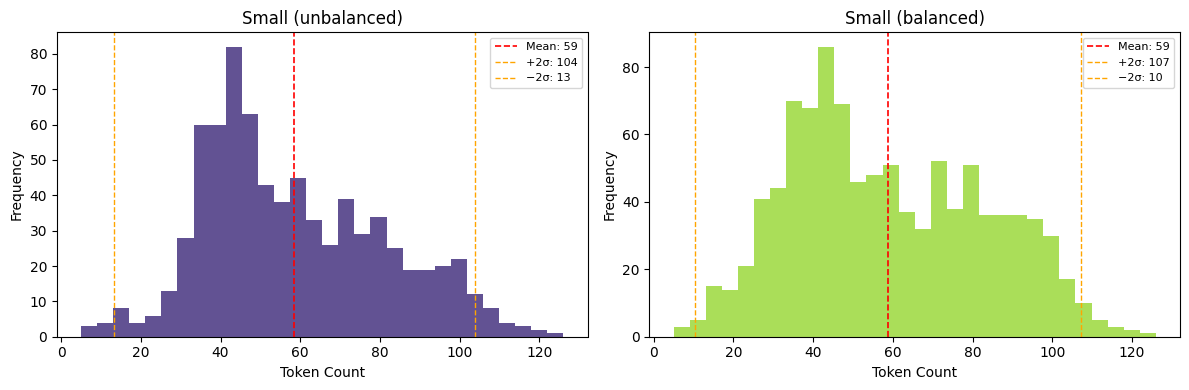

In [19]:
from evaluation.plot_style import CMAP_SEQUENTIAL_PRIMARY


# Shared histogram helper
def _token_hist_panel(ax, token_counts, title, color=None):
    arr = np.array(token_counts, dtype=float)
    mean = arr.mean()
    std = arr.std()
    ax.hist(arr, bins=30, alpha=0.85, color=color)
    ax.axvline(
        mean, color="red", linestyle="--", linewidth=1.2, label=f"Mean: {mean:.0f}"
    )
    ax.axvline(
        mean + 2 * std,
        color="orange",
        linestyle="--",
        linewidth=1.0,
        label=f"+2σ: {mean + 2 * std:.0f}",
    )
    ax.axvline(
        max(0, mean - 2 * std),
        color="orange",
        linestyle="--",
        linewidth=1.0,
        label=f"−2σ: {max(0, mean - 2 * std):.0f}",
    )
    ax.set_title(title)
    ax.set_xlabel("Token Count")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=8)


# --- Figure 1 — Small datasets ---
_colors = mpl.colormaps[CMAP_SEQUENTIAL_PRIMARY](np.linspace(0.15, 0.85, 2))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
_token_hist_panel(
    axes[0], stats_small_unbal["token_counts"], "Small (unbalanced)", color=_colors[0]
)
_token_hist_panel(
    axes[1], stats_small_bal["token_counts"], "Small (balanced)", color=_colors[1]
)
plt.tight_layout()
fig.savefig(DATA_DIR / "figures" / "ds_small_hist.pdf", bbox_inches="tight")
plt.show()

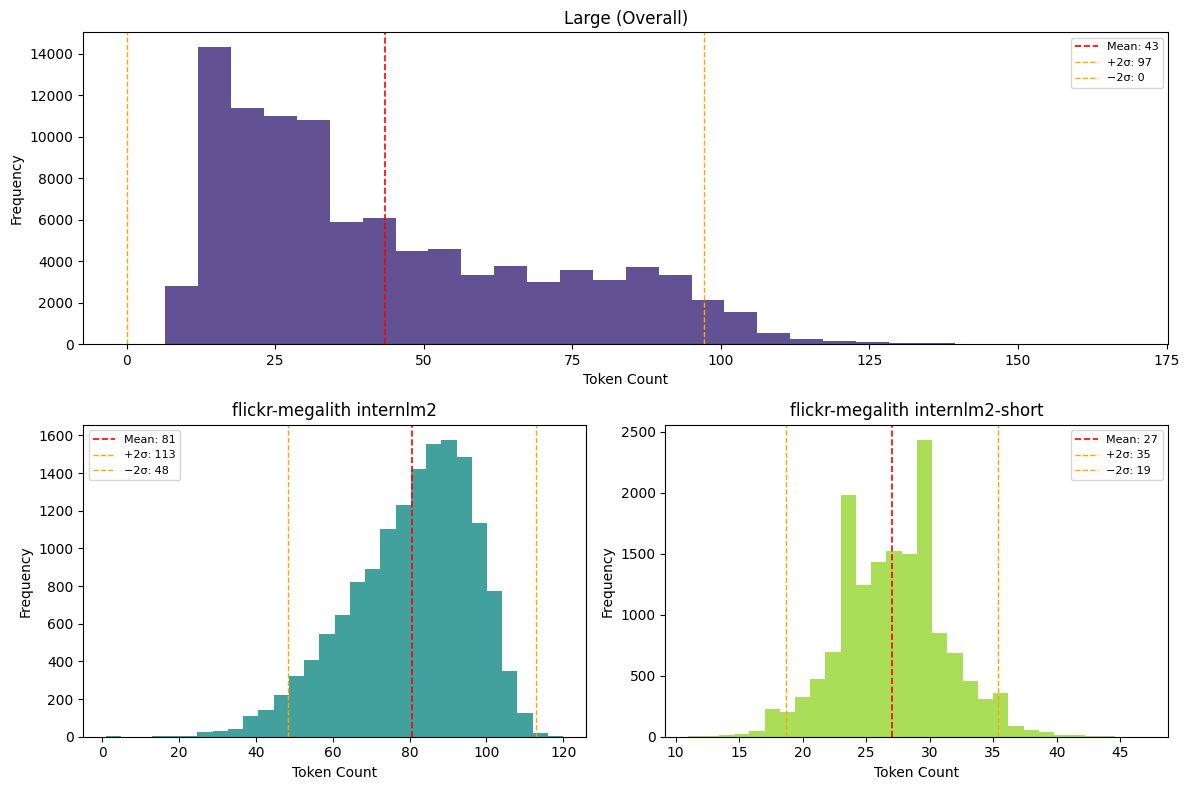

In [20]:
# --- Figure 2 — Large overall + artif_5, artif_4 ---
_colors = mpl.colormaps[CMAP_SEQUENTIAL_PRIMARY](np.linspace(0.15, 0.85, 3))
fig, axes = plt.subplot_mosaic(
    [["overall", "overall"], ["artif_5", "artif_4"]],
    figsize=(12, 8),
)
_token_hist_panel(
    axes["overall"], doc_token_counts, "Large (Overall)", color=_colors[0]
)
_token_hist_panel(
    axes["artif_5"],
    doc_token_counts_by_dataset["artif_5"],
    LARGE_DS_NAME_MAP["artif_5"],
    color=_colors[1],
)
_token_hist_panel(
    axes["artif_4"],
    doc_token_counts_by_dataset["artif_4"],
    LARGE_DS_NAME_MAP["artif_4"],
    color=_colors[2],
)
plt.tight_layout()
fig.savefig(DATA_DIR / "figures" / "ds_large_hist1.pdf", bbox_inches="tight")
plt.show()

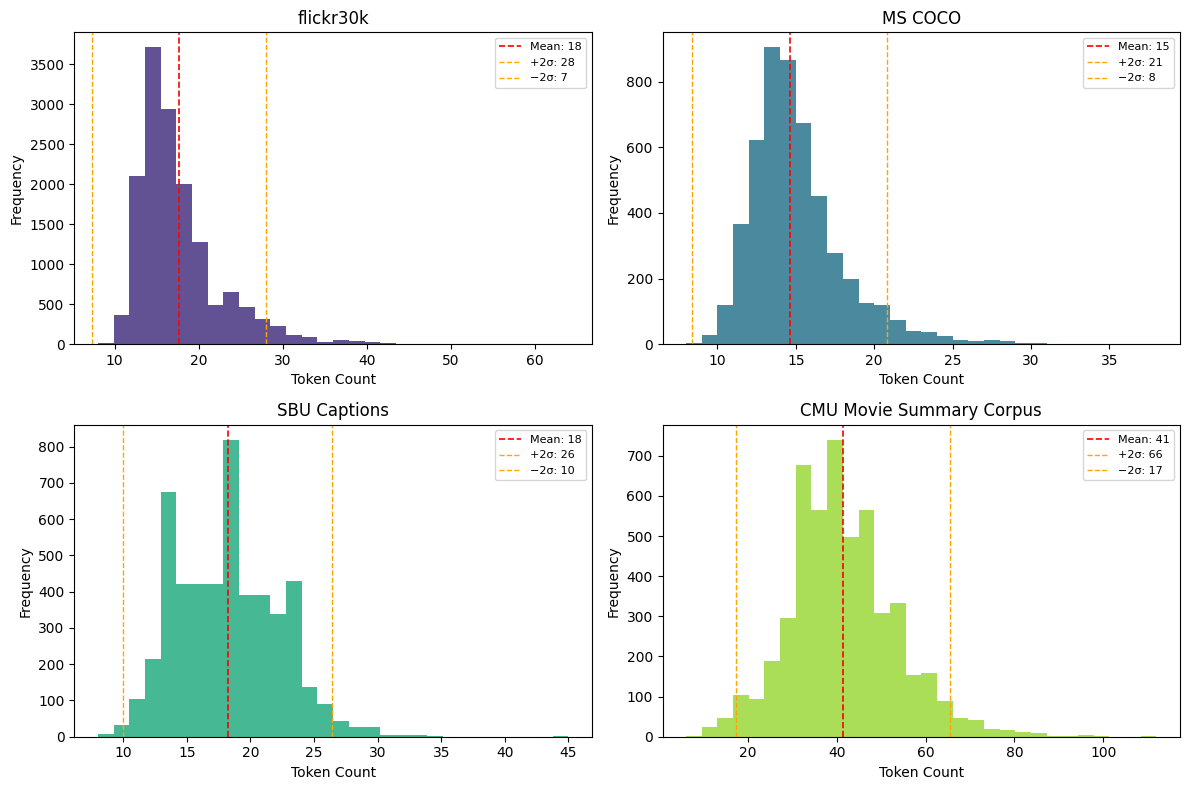

In [21]:
# --- Figure 3 — flickr30k, coco, sbu, movie_summaries ---
_colors = mpl.colormaps[CMAP_SEQUENTIAL_PRIMARY](np.linspace(0.15, 0.85, 4))
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, ds, color in zip(
    axes.flat, ["flickr30k", "coco", "sbu", "movie_summaries"], _colors
):
    _token_hist_panel(
        ax, doc_token_counts_by_dataset[ds], LARGE_DS_NAME_MAP[ds], color=color
    )
plt.tight_layout()
fig.savefig(DATA_DIR / "figures" / "ds_large_hist2.pdf", bbox_inches="tight")
plt.show()

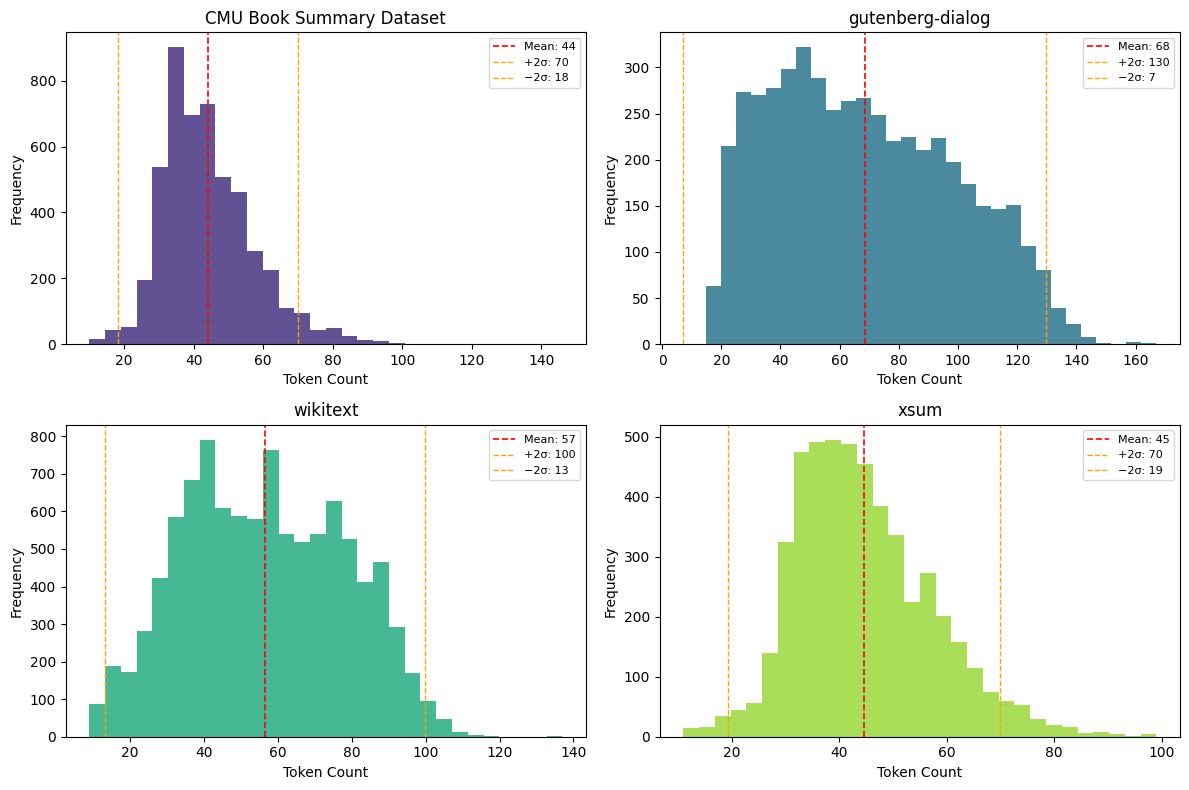

In [22]:
# --- Figure 4 — book_summaries, book_dialogs, wiki, news ---


_colors = mpl.colormaps[CMAP_SEQUENTIAL_PRIMARY](np.linspace(0.15, 0.85, 4))
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, ds, color in zip(
    axes.flat, ["book_summaries", "book_dialogs", "wiki", "news"], _colors
):
    _token_hist_panel(
        ax, doc_token_counts_by_dataset[ds], LARGE_DS_NAME_MAP[ds], color=color
    )
plt.tight_layout()
fig.savefig(DATA_DIR / "figures" / "ds_large_hist3.pdf", bbox_inches="tight")
plt.show()

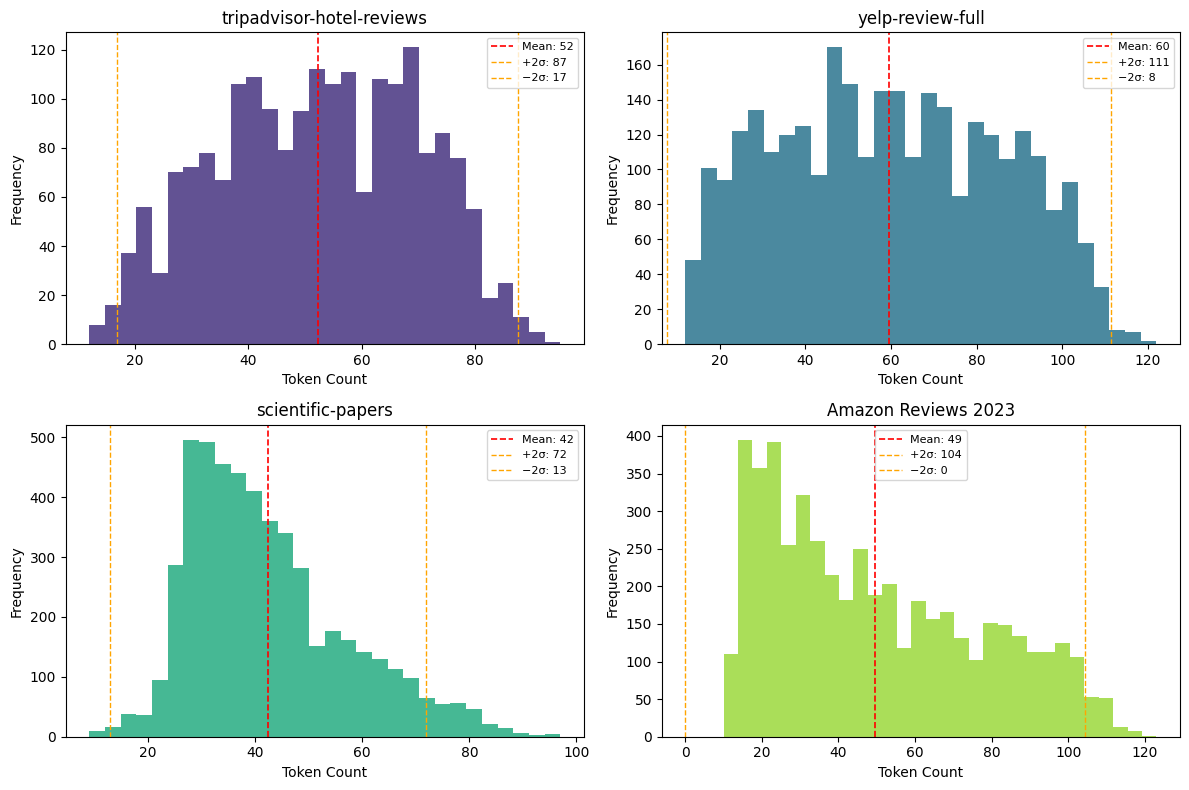

In [23]:
# --- Figure 5 — hotels, yelp, arxiv, amazon_reviews ---


_colors = mpl.colormaps[CMAP_SEQUENTIAL_PRIMARY](np.linspace(0.15, 0.85, 4))
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, ds, color in zip(
    axes.flat, ["hotels", "yelp", "arxiv", "amazon_reviews"], _colors
):
    _token_hist_panel(
        ax, doc_token_counts_by_dataset[ds], LARGE_DS_NAME_MAP[ds], color=color
    )
plt.tight_layout()
fig.savefig(DATA_DIR / "figures" / "ds_large_hist4.pdf", bbox_inches="tight")
plt.show()